# SRP v4 — Step 3: Does Attention Earn Its Place?

Step 1 measured the weak-learner ensemble with the simplest possible readout (mean-pool): **R² ≈ 0.788**.
Step 2 built a causal attention stage and *proved* the information staircase (expert *i* sees only experts *1..i*).

This notebook asks whether that staircase actually helps predict house prices, **and if so, where the gain comes from.**

### The arms

Every arm uses the **same 16 weak learners, the same prediction head, the same training loop.**
Only the way the 16 expert opinions are combined differs.

| Arm | How opinions are combined | Params | Role |
|---|---|---|---|
| **Mean-pool** | plain average | ~11.6k | Step-1 control, reproduced |
| **Mean-pool (wide head)** | plain average, then a much bigger head | ~37.6k | **Capacity control** — same size as attention, no sequencing |
| **Bidirectional attn** | attention, every expert sees every other | ~37.7k | Attention **without** order |
| **Causal attn** | attention, expert *i* sees *1..i* | ~37.7k | The staircase |
| **Causal attn + deep sup.** | causal + every position predicts, exponentially weighted loss | ~37.7k | *Supplementary:* V2's full recipe |

Plus two reference lines, not arms: **PlainMLP** (one ordinary MLP) and **tuned XGBoost**.

### What each comparison isolates

| Comparison | Question it answers |
|---|---|
| Wide head − Mean-pool | Does extra **capacity** alone help? |
| Bidirectional − Wide head | Is **attention** a better use of those parameters than an MLP? |
| Causal − Wide head | Does **the proposed architecture** beat a size-matched plain alternative? *(the key question)* |
| Causal − Bidirectional | Does the **causal ordering** specifically matter? *(never measured in V1–V3)* |
| Causal+DS − Causal | Does **deep supervision** add anything on top? |

### Paired design

For a given seed, every arm gets **bit-identical weak-learner weights, identical feature subsets and identical
batch order.** So for each seed, the difference between two arms comes only from the aggregator (plus dropout
noise). That lets us compare arms seed by seed and run a paired t-test, which is much more sensitive than
comparing two independent averages.

### Protocol (unchanged from step 1)
60/20/20 split · QuantileTransformer fit on train only · early stopping on the **final prediction's** validation
loss with best checkpoint restored · test set touched only for the final table · **5 seeds**.

## 0. Setup

In [1]:
import os, sys, time, warnings
warnings.filterwarnings("ignore")

PROJECT_DIR = os.getcwd()
sys.path.insert(0, PROJECT_DIR)
# Parallel workers are fresh processes: make sure they can import this folder's modules too.
os.environ["PYTHONPATH"] = PROJECT_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from joblib import Parallel, delayed

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

from weak_learners import WeakLearnerConfig
from attention import AttentionConfig
from model import make_arm, ARM_NAMES
from training import regression_metrics

SEED  = 42
SEEDS = (0, 1, 2, 3, 4)

# Parallelism: training is dominated by CPU dropout-mask generation, which barely speeds up
# with more threads per run, so we run many small runs side by side instead.
# On a 2-core machine (e.g. Colab CPU) this falls back to running one job at a time.
THREADS_PER_JOB = 2
N_JOBS = max(1, min(8, (os.cpu_count() or 2) // THREADS_PER_JOB))

ENS_KW = dict(num_learners=16, hidden_dim=16, embed_dim=32, depth=1, dropout=0.1, feature_frac=0.7)
ATT_KW = dict(embed_dim=32, num_heads=4, attn_depth=2, ff_mult=4, dropout=0.1, need_weights=False)
TRAIN_KW = dict(epochs=200, lr=1e-3, batch_size=256, weight_decay=1e-4, patience=20)

LABEL = {
    "meanpool":      "Mean-pool",
    "meanpool_wide": "Mean-pool (wide head)",
    "bidirectional": "Bidirectional attn",
    "causal":        "Causal attn",
    "causal_ds":     "Causal attn + deep sup.",
    "PlainMLP":      "PlainMLP (reference)",
    "XGBoost":       "XGBoost (reference)",
}
COLOR = {
    "meanpool":      "#b9b0ee",
    "meanpool_wide": "#7b5cff",
    "bidirectional": "#1fa899",
    "causal":        "#e0527a",
    "causal_ds":     "#9c1c47",
    "PlainMLP":      "#4c8dff",
    "XGBoost":       "#ff8a3d",
}
ARMS = list(ARM_NAMES)

sns.set_theme(style="whitegrid", context="notebook")

def show(df, fmt=None, style=None):
    # Styled table when jinja2 is available, plain rounded table otherwise.
    try:
        s = df.style.format(fmt or {}, na_rep="—")
        display(style(s) if style else s)
    except (AttributeError, ImportError):
        display(df.round(4))

print(f"torch {torch.__version__} | {os.cpu_count()} CPUs -> {N_JOBS} parallel jobs x {THREADS_PER_JOB} threads")

torch 2.11.0+cu130 | 16 CPUs -> 8 parallel jobs x 2 threads


## 1. Data — identical split and preprocessing to step 1

In [2]:
data = fetch_california_housing()
X_all, y_all = data.data.astype(np.float64), data.target.astype(np.float64)

X_tmp, X_te, y_tmp, y_te = train_test_split(X_all, y_all, test_size=0.20, random_state=SEED)
X_tr,  X_va, y_tr,  y_va = train_test_split(X_tmp, y_tmp, test_size=0.25, random_state=SEED)

qt = QuantileTransformer(output_distribution="normal", n_quantiles=1000, random_state=SEED).fit(X_tr)

ARRAYS = {
    "Xtr": qt.transform(X_tr).astype(np.float32), "ytr": y_tr.astype(np.float32),
    "Xva": qt.transform(X_va).astype(np.float32), "yva": y_va.astype(np.float32),
    "Xte": qt.transform(X_te).astype(np.float32), "yte": y_te.astype(np.float32),
}
IN_DIM = ARRAYS["Xtr"].shape[1]
print(f"train {len(y_tr):,} | val {len(y_va):,} | test {len(y_te):,} | features {IN_DIM}")

train 12,384 | val 4,128 | test 4,128 | features 8


## 2. The arms — verifying they really are capacity-matched

Before training anything, check that the comparison is fair: the three attention arms and the wide-head
control should have (almost) the same number of parameters.

In [3]:
rows = []
for arm in ARMS:
    torch.manual_seed(0)
    m = make_arm(arm, IN_DIM, WeakLearnerConfig(**ENS_KW, seed=0), AttentionConfig(**ATT_KW))
    head = sum(p.numel() for p in m.head.parameters())
    stage = sum(p.numel() for p in m.stage.parameters()) if m.stage is not None else 0
    rows.append({"arm": LABEL[arm], "weak learners": m.ensemble.num_parameters(),
                 "attention stage": stage, "head": head, "total": m.num_parameters(),
                 "head shape": f"{m.config.head_depth} x {m.config.head_hidden or ENS_KW['embed_dim']}"})
arm_table = pd.DataFrame(rows).set_index("arm")
ref_total = arm_table.loc["Causal attn", "total"]
arm_table["vs attention"] = (arm_table["total"] / ref_total - 1).map(lambda v: f"{v:+.1%}")
display(arm_table)
print("Every arm has the same 10,496 weak-learner parameters. The wide-head control spends the attention")
print("stage's ~26k parameters on a 2-layer MLP head instead, landing within 0.2% of the attention arms.")

,weak learners,attention stage,head,total,head shape,vs attention
arm,,,,,,
Mean-pool,10496,0,1153,11649,1 x 32,-69.1%
Mean-pool (wide head),10496,0,27149,37645,2 x 148,-0.1%
Bidirectional attn,10496,26048,1153,37697,1 x 32,+0.0%
Causal attn,10496,26048,1153,37697,1 x 32,+0.0%
Causal attn + deep sup.,10496,26048,1153,37697,1 x 32,+0.0%


Every arm has the same 10,496 weak-learner parameters. The wide-head control spends the attention
stage's ~26k parameters on a 2-layer MLP head instead, landing within 0.2% of the attention arms.


## 3. Reference: tuned XGBoost

Same randomized search as step 1 (25 configurations, selected on validation R²). This is a reference line
for the charts, not part of the ablation.

In [4]:
def tune_xgb(n_iter=25, seed=SEED):
    rng = np.random.RandomState(seed)
    grid = {"n_estimators": [200, 400, 600, 800], "max_depth": [3, 4, 6, 8, 10],
            "learning_rate": [0.02, 0.05, 0.1, 0.2], "subsample": [0.6, 0.8, 1.0],
            "colsample_bytree": [0.6, 0.8, 1.0], "min_child_weight": [1, 3, 5],
            "reg_lambda": [0.1, 1.0, 5.0]}
    best = (-np.inf, None, None)
    for _ in range(n_iter):
        p = {k: v[rng.randint(len(v))] for k, v in grid.items()}
        m = XGBRegressor(random_state=seed, n_jobs=-1, tree_method="hist", **p).fit(X_tr, y_tr)
        s = r2_score(y_va, m.predict(X_va))
        if s > best[0]:
            best = (s, p, m)
    return best

t0 = time.time()
xgb_val, xgb_params, xgb_model = tune_xgb()
XGB_TEST = regression_metrics(y_te, xgb_model.predict(X_te))
print(f"XGBoost tuned in {time.time()-t0:.0f}s | val R² {xgb_val:.4f} | TEST R² {XGB_TEST['r2']:.4f}")

XGBoost tuned in 28s | val R² 0.8499 | TEST R² 0.8471


## 4. Train every arm on every seed

One job = one (arm, seed) pair, **30 jobs** in total (5 arms + PlainMLP, 5 seeds each). Each job trains with
the shared `training.train_model` contract, then computes its own diagnostics on the trained model before
returning: test metrics, expert diversity, attention maps, and the per-position R² for deep supervision.

Jobs run in parallel, slowest arms first. **This is the long cell** (~15–25 min on 16 cores).

In [5]:
class PlainMLP(nn.Module):
    # Same reference model as step 1.
    def __init__(self, in_dim, hidden=128, depth=3, dropout=0.1):
        super().__init__()
        layers, d = [], in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.ReLU(), nn.Dropout(dropout)]
            d = hidden
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(-1)


def run_job(arm, seed, arrays, ens_kw, att_kw, train_kw, project_dir, threads):
    # Executed inside a worker process: import everything here, not at module level.
    import sys
    if project_dir not in sys.path:
        sys.path.insert(0, project_dir)
    import numpy as np, torch
    from sklearn.metrics import r2_score
    from weak_learners import WeakLearnerConfig
    from attention import AttentionConfig
    from model import make_arm
    from training import train_model, predict, regression_metrics

    torch.set_num_threads(threads)
    T = lambda a: torch.tensor(a, dtype=torch.float32)
    data = {k: T(v) for k, v in arrays.items()}
    yte = arrays["yte"]

    torch.manual_seed(seed); np.random.seed(seed)
    if arm == "PlainMLP":
        model = PlainMLP(data["Xtr"].shape[1])
    else:
        model = make_arm(arm, data["Xtr"].shape[1],
                         WeakLearnerConfig(**ens_kw, seed=seed), AttentionConfig(**att_kw))
    model, hist = train_model(model, data, seed=seed, **train_kw)

    res = {"arm": arm, "seed": seed,
           "n_params": sum(p.numel() for p in model.parameters()),
           **regression_metrics(yte, predict(model, data["Xte"])),
           "best_epoch": hist["best_epoch"] + 1, "epochs_run": hist["epochs_run"],
           "seconds": hist["seconds"], "history": {"train": hist["train"], "val": hist["val"]}}
    if arm == "PlainMLP":
        return res

    sim, off = model.ensemble.diversity_stats(data["Xva"])
    res["div_sim"], res["div_off"] = sim.cpu().numpy(), off

    model.eval()
    with torch.no_grad():
        out = model(data["Xte"], need_weights=model.stage is not None)
    if out["attn"] is not None:
        K = out["attn"][0].shape[-1]
        res["attn_mean"] = [a.mean(0).cpu().numpy() for a in out["attn"]]
        # Normalised entropy of the readout (last) row: 1.0 == uniform == behaves like mean-pooling.
        ent = []
        for a in out["attn"]:
            p = a[:, -1, :].clamp_min(1e-12)
            ent.append(float((-(p * p.log()).sum(-1) / np.log(K)).mean()))
        res["last_row_entropy"] = ent
    if out["step_preds"] is not None:
        sp = out["step_preds"].cpu().numpy()
        res["stage_r2"] = np.array([r2_score(yte, sp[:, i]) for i in range(sp.shape[1])])
    return res


# Slowest arms first so the pool stays busy until the end.
ORDER = ["causal_ds", "causal", "bidirectional", "meanpool_wide", "meanpool", "PlainMLP"]
jobs = [(arm, s) for arm in ORDER for s in SEEDS]
print(f"{len(jobs)} jobs on {N_JOBS} workers ...")

t0 = time.time()
RESULTS = []
for r in Parallel(n_jobs=N_JOBS, return_as="generator")(
        delayed(run_job)(arm, s, ARRAYS, ENS_KW, ATT_KW, TRAIN_KW, PROJECT_DIR, THREADS_PER_JOB)
        for arm, s in jobs):
    RESULTS.append(r)
    print(f"  [{len(RESULTS):2d}/{len(jobs)}] {LABEL[r['arm']]:26s} seed {r['seed']}  "
          f"R²={r['r2']:.4f}  best epoch {r['best_epoch']:3d}  ({r['seconds']/60:.1f} min)  "
          f"elapsed {(time.time()-t0)/60:.1f} min", flush=True)

print(f"\nall done in {(time.time()-t0)/60:.1f} min")

30 jobs on 8 workers ...


  [ 1/30] Causal attn + deep sup.    seed 0  R²=0.8069  best epoch  52  (7.3 min)  elapsed 7.3 min


  [ 2/30] Causal attn + deep sup.    seed 1  R²=0.8108  best epoch 122  (14.0 min)  elapsed 14.1 min


  [ 3/30] Causal attn + deep sup.    seed 2  R²=0.8108  best epoch  55  (7.4 min)  elapsed 14.1 min


  [ 4/30] Causal attn + deep sup.    seed 3  R²=0.8072  best epoch  68  (8.5 min)  elapsed 14.1 min


...

  [27/30] PlainMLP (reference)       seed 1  R²=0.8042  best epoch 168  (0.8 min)  elapsed 19.6 min


  [28/30] PlainMLP (reference)       seed 2  R²=0.8027  best epoch 104  (0.6 min)  elapsed 19.6 min


  [29/30] PlainMLP (reference)       seed 3  R²=0.8035  best epoch 113  (0.6 min)  elapsed 19.6 min


  [30/30] PlainMLP (reference)       seed 4  R²=0.8061  best epoch 139  (0.6 min)  elapsed 19.6 min



all done in 19.6 min


## 5. Results

In [6]:
res = pd.DataFrame([{k: v for k, v in r.items()
                     if k in ("arm", "seed", "n_params", "rmse", "mae", "r2", "best_epoch", "seconds")}
                    for r in RESULTS])

SHOW = ARMS + ["PlainMLP"]
g = res.groupby("arm")
table = pd.DataFrame({
    "Test R²":    g["r2"].mean(),
    "± std":      g["r2"].std(),
    "Test RMSE":  g["rmse"].mean(),
    "Test MAE":   g["mae"].mean(),
    "Params":     g["n_params"].first().map("{:,}".format),
    "Best epoch": g["best_epoch"].mean().round(0).astype(int),
    "Min / run":  (g["seconds"].mean() / 60).round(1),
}).reindex(SHOW)
table.loc["XGBoost"] = [XGB_TEST["r2"], 0.0, XGB_TEST["rmse"], XGB_TEST["mae"], "—", np.nan, np.nan]
table["Gap to XGBoost"] = table["Test R²"] - XGB_TEST["r2"]
table.index = [LABEL[i] for i in table.index]

print(f"TEST-SET RESULTS — California Housing, {len(SEEDS)} seeds per neural model")
show(table, {"Test R²": "{:.4f}", "± std": "{:.4f}", "Test RMSE": "{:.4f}", "Test MAE": "{:.4f}",
             "Gap to XGBoost": "{:+.4f}", "Best epoch": "{:.0f}", "Min / run": "{:.1f}"},
     style=lambda s: s.background_gradient(subset=["Test R²"], cmap="Purples"))

per_seed = res.pivot(index="seed", columns="arm", values="r2")[SHOW]
per_seed.columns = [LABEL[c] for c in per_seed.columns]
print("\nPer-seed test R² — read across a row: same seed, same experts, different aggregator")
show(per_seed, {c: "{:.4f}" for c in per_seed.columns},
     style=lambda s: s.highlight_max(axis=1, color="#e8e0ff"))

TEST-SET RESULTS — California Housing, 5 seeds per neural model


,Test R²,± std,Test RMSE,Test MAE,Params,Best epoch,Min / run,Gap to XGBoost
Mean-pool,0.7889,0.0027,0.5260,0.3573,"11,649",192.0,2.6,-0.0582
Mean-pool (wide head),0.8104,0.0050,0.4984,0.3321,"37,645",166.0,2.9,-0.0367
Bidirectional attn,0.8072,0.0019,0.5027,0.3326,"37,697",59.0,6.8,-0.0399
Causal attn,0.8074,0.0055,0.5024,0.3331,"37,697",74.0,8.6,-0.0397
Causal attn + deep sup.,0.8096,0.0024,0.4995,0.3270,"37,697",72.0,9.0,-0.0374
PlainMLP (reference),0.8030,0.0028,0.5081,0.3321,"34,305",126.0,0.6,-0.0441
XGBoost (reference),0.8471,0.0000,0.4477,0.2899,—,NaN,NaN,0.0000



Per-seed test R² — read across a row: same seed, same experts, different aggregator


,Mean-pool,Mean-pool (wide head),Bidirectional attn,Causal attn,Causal attn + deep sup.,PlainMLP (reference)
seed,,,,,,
0,0.7923,0.8043,0.8089,0.8015,0.8069,0.7985
1,0.7907,0.8082,0.8063,0.8015,0.8108,0.8042
2,0.7888,0.8084,0.8060,0.8090,0.8108,0.8027
3,0.7871,0.8164,0.8052,0.8121,0.8072,0.8035
4,0.7855,0.8148,0.8096,0.8127,0.8124,0.8061


### 5.1 Headline chart

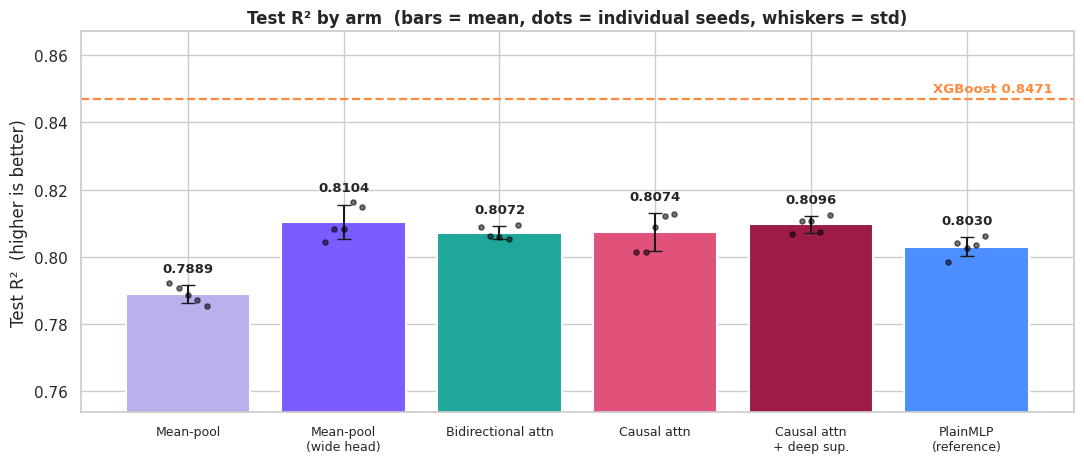

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.8))
means = [res[res.arm == a].r2.mean() for a in SHOW]
sds   = [res[res.arm == a].r2.std()  for a in SHOW]
x = np.arange(len(SHOW))
ax.bar(x, means, yerr=sds, capsize=5, color=[COLOR[a] for a in SHOW], edgecolor="white", linewidth=1.5)
for a_i, a in enumerate(SHOW):      # individual seeds as dots: the spread is part of the result
    ys = res[res.arm == a].r2.values
    ax.scatter(np.full_like(ys, a_i) + np.linspace(-0.12, 0.12, len(ys)), ys,
               s=14, color="black", alpha=.55, zorder=3)
    ax.text(a_i, means[a_i] + sds[a_i] + 0.004, f"{means[a_i]:.4f}", ha="center",
            fontweight="bold", fontsize=9.5)
ax.axhline(XGB_TEST["r2"], color=COLOR["XGBoost"], ls="--", lw=1.6)
ax.text(len(SHOW) - 0.45, XGB_TEST["r2"] + 0.002, f"XGBoost {XGB_TEST['r2']:.4f}",
        color=COLOR["XGBoost"], ha="right", fontsize=9.5, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels([LABEL[a].replace(" (", "\n(").replace(" + ", "\n+ ") for a in SHOW], fontsize=9)
ax.set_ylabel("Test R²  (higher is better)")
ax.set_ylim(min(means) - 0.035, XGB_TEST["r2"] + 0.02)
ax.set_title("Test R² by arm  (bars = mean, dots = individual seeds, whiskers = std)", fontweight="bold")
plt.tight_layout(); plt.show()

## 6. Decomposition — where does the R² come from?

Because the arms are paired by seed, we can take the difference **within each seed** and then average.
Each comparison below is a paired t-test over 5 seeds. The **95% confidence interval** is the key column:
it is the range of effect sizes consistent with the data. An interval that crosses zero means *no evidence of an
effect*, and its width tells you how large an effect could still be hiding in the noise.

In [8]:
wide = res.pivot(index="seed", columns="arm", values="r2")

COMPARISONS = [
    ("Capacity",                     "meanpool_wide", "meanpool",
     "extra parameters, no sequencing"),
    ("Attention vs same-size MLP",   "bidirectional", "meanpool_wide",
     "attention (no order) vs spending the params on a head"),
    ("Causal attn vs same-size MLP", "causal",        "meanpool_wide",
     "THE KEY QUESTION: proposed architecture vs a plain alternative"),
    ("Causal ordering",              "causal",        "bidirectional",
     "does the staircase specifically matter?"),
    ("Deep supervision",             "causal_ds",     "causal",
     "V2's weighted per-position loss, on top of causal"),
    ("V2 recipe vs same-size MLP",   "causal_ds",     "meanpool_wide",
     "the full presented architecture vs a plain alternative"),
]

def paired(a, b):
    d = (wide[a] - wide[b]).values
    n = len(d)
    mean, sd = d.mean(), d.std(ddof=1)
    se = sd / np.sqrt(n)
    tcrit = stats.t.ppf(0.975, n - 1)
    t, p = stats.ttest_rel(wide[a].values, wide[b].values)
    return d, mean, sd, mean - tcrit * se, mean + tcrit * se, t, p

rows, DELTAS = [], {}
for name, a, b, what in COMPARISONS:
    d, mean, sd, lo, hi, t, p = paired(a, b)
    DELTAS[name] = d
    wins = int((d > 0).sum())
    if p < 0.05:
        verdict = "REAL gain" if mean > 0 else "REAL loss"
    else:
        verdict = "within noise"
    rows.append({"comparison": name, "A − B": f"{LABEL[a]}  −  {LABEL[b]}",
                 "mean ΔR²": mean, "95% CI low": lo, "95% CI high": hi,
                 "A wins": f"{wins}/{len(d)}", "p (paired t)": p, "verdict": verdict, "isolates": what})
decomp = pd.DataFrame(rows).set_index("comparison")

def _color_verdict(v):
    return {"REAL gain": "background-color:#d8f5e3", "REAL loss": "background-color:#fbdada"}.get(v, "")
show(decomp, {"mean ΔR²": "{:+.4f}", "95% CI low": "{:+.4f}", "95% CI high": "{:+.4f}",
              "p (paired t)": "{:.3f}"},
     style=lambda s: s.map(_color_verdict, subset=["verdict"]))
print("Caveat: 5 seeds on one dataset. 'REAL' means consistent across these seeds on California Housing,")
print("not a general law. 'within noise' means no detectable effect at this sample size — check the CI width.")

,A − B,mean ΔR²,95% CI low,95% CI high,A wins,p (paired t),verdict,isolates
comparison,,,,,,,,
Capacity,Mean-pool (wide head) − Mean-pool,0.0215,0.0121,0.0310,5/5,0.0032,REAL gain,"extra parameters, no sequencing"
Attention vs same-size MLP,Bidirectional attn − Mean-pool (wide head),-0.0032,-0.0103,0.0039,1/5,0.2754,within noise,attention (no order) vs spending the params on...
Causal attn vs same-size MLP,Causal attn − Mean-pool (wide head),-0.0031,-0.0064,0.0003,1/5,0.0659,within noise,THE KEY QUESTION: proposed architecture vs a p...
Causal ordering,Causal attn − Bidirectional attn,0.0002,-0.0073,0.0076,3/5,0.9507,within noise,does the staircase specifically matter?
Deep supervision,Causal attn + deep sup. − Causal attn,0.0023,-0.0045,0.0090,3/5,0.4049,within noise,"V2's weighted per-position loss, on top of causal"
V2 recipe vs same-size MLP,Causal attn + deep sup. − Mean-pool (wide head),-0.0008,-0.0072,0.0056,3/5,0.7479,within noise,the full presented architecture vs a plain alt...


Caveat: 5 seeds on one dataset. 'REAL' means consistent across these seeds on California Housing,
not a general law. 'within noise' means no detectable effect at this sample size — check the CI width.


### 6.1 The same comparisons, seed by seed

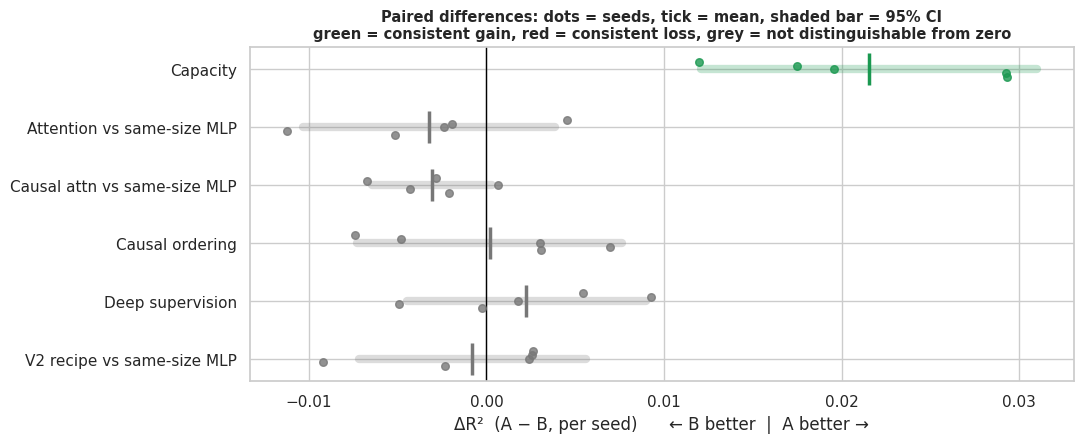

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.6))
names = [c[0] for c in COMPARISONS]
for i, name in enumerate(names):
    d = DELTAS[name]
    row = decomp.loc[name]
    col = "#1a9850" if row["verdict"] == "REAL gain" else "#d73027" if row["verdict"] == "REAL loss" else "#777"
    ax.plot([row["95% CI low"], row["95% CI high"]], [i, i], color=col, lw=6, alpha=.25, solid_capstyle="round")
    ax.scatter(d, np.full_like(d, i) + np.linspace(-0.13, 0.13, len(d)), color=col, s=30, zorder=3, alpha=.8)
    ax.scatter([row["mean ΔR²"]], [i], marker="|", s=500, color=col, lw=2.5, zorder=4)
    ax.text(ax.get_xlim()[1] if i == 0 else 0, i, "", fontsize=8)
ax.axvline(0, color="black", lw=1)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_xlabel("ΔR²  (A − B, per seed)      ← B better  |  A better →")
ax.set_title("Paired differences: dots = seeds, tick = mean, shaded bar = 95% CI\n"
             "green = consistent gain, red = consistent loss, grey = not distinguishable from zero",
             fontweight="bold", fontsize=10.5)
plt.tight_layout(); plt.show()

### 6.2 Waterfall — building up from mean-pool, one mechanism at a time

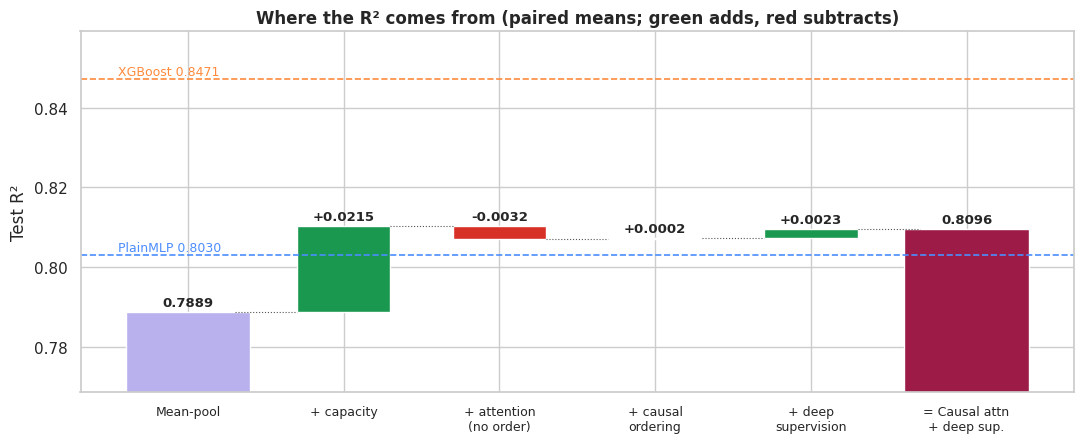

In [10]:
steps = [("Mean-pool", wide["meanpool"].mean(), "base"),
         ("+ capacity", (wide["meanpool_wide"] - wide["meanpool"]).mean(), "delta"),
         ("+ attention\n(no order)", (wide["bidirectional"] - wide["meanpool_wide"]).mean(), "delta"),
         ("+ causal\nordering", (wide["causal"] - wide["bidirectional"]).mean(), "delta"),
         ("+ deep\nsupervision", (wide["causal_ds"] - wide["causal"]).mean(), "delta"),
         ("= Causal attn\n+ deep sup.", wide["causal_ds"].mean(), "total")]

fig, ax = plt.subplots(figsize=(11, 4.6))
level = 0.0
for i, (lab, val, kind) in enumerate(steps):
    if kind == "base":
        ax.bar(i, val, color=COLOR["meanpool"]); level = val; top = val
    elif kind == "total":
        ax.bar(i, val, color=COLOR["causal_ds"]); top = val
    else:
        ax.bar(i, val, bottom=level, color="#1a9850" if val >= 0 else "#d73027", width=0.6)
        top = level + max(val, 0); level += val
    txt = f"{val:.4f}" if kind != "delta" else f"{val:+.4f}"
    ax.text(i, top + 0.0015, txt, ha="center", fontsize=9.5, fontweight="bold")
    if i < len(steps) - 1:
        ax.plot([i + 0.3, i + 0.7], [level, level], color="#555", lw=0.8, ls=":")
for ref, c in [("PlainMLP", COLOR["PlainMLP"])]:
    v = wide[ref].mean()
    ax.axhline(v, color=c, ls="--", lw=1.2); ax.text(-0.45, v + 0.001, f"PlainMLP {v:.4f}", color=c, fontsize=9)
ax.axhline(XGB_TEST["r2"], color=COLOR["XGBoost"], ls="--", lw=1.2)
ax.text(-0.45, XGB_TEST["r2"] + 0.001, f"XGBoost {XGB_TEST['r2']:.4f}", color=COLOR["XGBoost"], fontsize=9)
ax.set_xticks(range(len(steps))); ax.set_xticklabels([s[0] for s in steps], fontsize=9)
lo = min(wide["meanpool"].mean(), min(level, wide["causal_ds"].mean())) - 0.02
ax.set_ylim(lo, XGB_TEST["r2"] + 0.012)
ax.set_ylabel("Test R²")
ax.set_title("Where the R² comes from (paired means; green adds, red subtracts)", fontweight="bold")
plt.tight_layout(); plt.show()

## 7. What did the attention actually learn?

A sanity check on the mechanism itself. Heatmaps show the average attention weight from each expert (row) to
each other expert (column), over the test set, for seed 0.

The number to watch is the **readout-row entropy**: how evenly the last token spreads its attention.
**1.0 means perfectly uniform**, which is mathematically the same as mean-pooling. A value near 1.0 means the
attention stage learned to *average*, and whatever gain it gives comes from its extra non-linear layers,
not from choosing which experts to listen to.

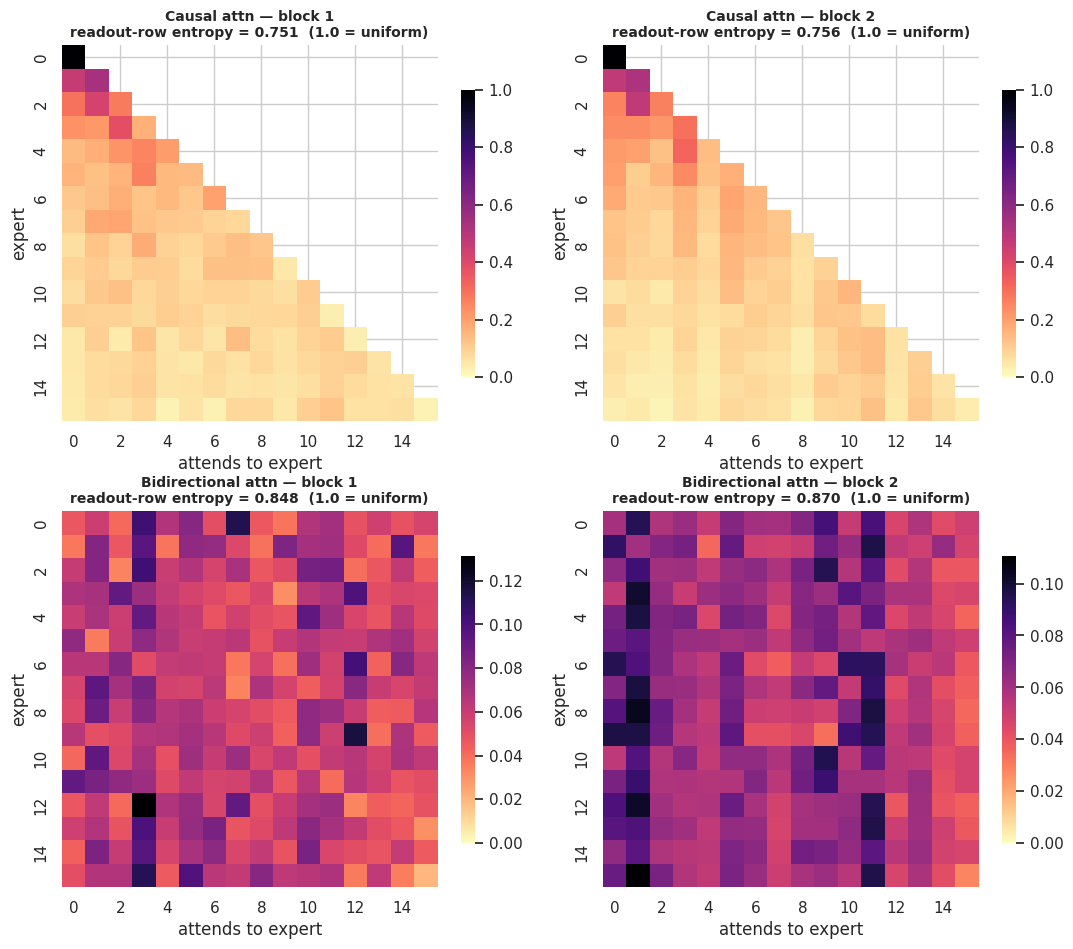

Readout-row entropy, mean over seeds (1.0 = uniform = same as mean-pooling):


block 1        block 2       
                           mean    std    mean    std
arm                                                  
Bidirectional attn        0.778  0.065   0.893  0.027
Causal attn               0.758  0.028   0.836  0.053
Causal attn + deep sup.   0.791  0.027   0.867  0.025

In [11]:
by = {(r["arm"], r["seed"]): r for r in RESULTS}
fig, axes = plt.subplots(2, 2, figsize=(11, 9.5))
for row, arm in enumerate(["causal", "bidirectional"]):
    r = by[(arm, SEEDS[0])]
    for blk in range(2):
        A = r["attn_mean"][blk]
        ax = axes[row, blk]
        mask = np.triu(np.ones_like(A, dtype=bool), k=1) if arm == "causal" else None
        sns.heatmap(A, ax=ax, cmap="magma_r", square=True, mask=mask, vmin=0,
                    cbar_kws={"shrink": .75}, xticklabels=2, yticklabels=2)
        ax.set_title(f"{LABEL[arm]} — block {blk+1}\nreadout-row entropy = {r['last_row_entropy'][blk]:.3f}"
                     f"  (1.0 = uniform)", fontsize=10, fontweight="bold")
        ax.set_xlabel("attends to expert"); ax.set_ylabel("expert")
plt.tight_layout(); plt.show()

ent = pd.DataFrame([{"arm": LABEL[r["arm"]], "seed": r["seed"],
                     "block 1": r["last_row_entropy"][0], "block 2": r["last_row_entropy"][1]}
                    for r in RESULTS if "last_row_entropy" in r])
print("Readout-row entropy, mean over seeds (1.0 = uniform = same as mean-pooling):")
display(ent.groupby("arm")[["block 1", "block 2"]].agg(["mean", "std"]).round(3))

## 8. Does attention change what the experts learn?

Step 1 found that mean-pool training pushes expert similarity from ~0.006 up to ~0.11: some pull toward
agreement, nowhere near collapse (1.0). Here we check whether putting an attention stage on top changes that,
e.g. whether the staircase pushes later experts to specialise, or lets them get lazy and copy each other.

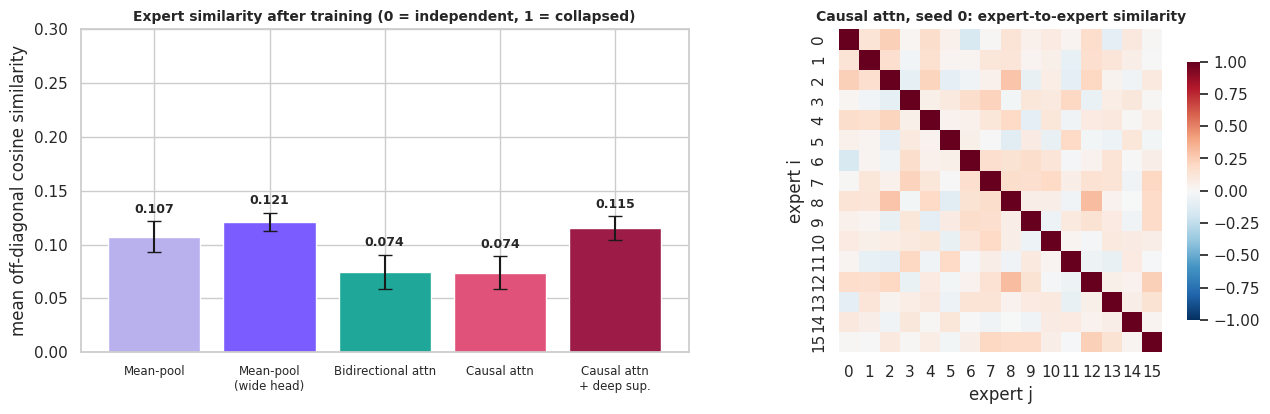

In [12]:
div = pd.DataFrame([{"arm": r["arm"], "seed": r["seed"], "div": r["div_off"]}
                    for r in RESULTS if "div_off" in r])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), gridspec_kw={"width_ratios": [1.2, 1]})
ax = axes[0]
m = div.groupby("arm")["div"].agg(["mean", "std"]).reindex(ARMS)
ax.bar(range(len(ARMS)), m["mean"], yerr=m["std"], capsize=5, color=[COLOR[a] for a in ARMS], edgecolor="white")
for i, v in enumerate(m["mean"]):
    ax.text(i, v + m["std"].iloc[i] + 0.008, f"{v:.3f}", ha="center", fontweight="bold", fontsize=9)
ax.set_xticks(range(len(ARMS))); ax.set_xticklabels([LABEL[a].replace(" (", "\n(").replace(" + ", "\n+ ") for a in ARMS], fontsize=8.5)
ax.set_ylabel("mean off-diagonal cosine similarity"); ax.set_ylim(0, max(0.3, (m["mean"] + m["std"]).max() * 1.25))
ax.set_title("Expert similarity after training (0 = independent, 1 = collapsed)", fontweight="bold", fontsize=10)

r = by[("causal", SEEDS[0])]
sns.heatmap(r["div_sim"], ax=axes[1], cmap="RdBu_r", vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8})
axes[1].set_title(f"Causal attn, seed {SEEDS[0]}: expert-to-expert similarity", fontweight="bold", fontsize=10)
axes[1].set_xlabel("expert j"); axes[1].set_ylabel("expert i")
plt.tight_layout(); plt.show()

## 9. The staircase: does each extra expert improve the prediction?

Only the deep-supervision arm trains *every* position to predict, so only it can be read out at every position.
Position *i* has seen experts *1..i*. If the architecture behaves like boosting, test R² should **rise steadily**
from position 1 (a single weak learner) to position 16 (the whole ensemble).

Remember the exponential weighting: with K=16 the last 3 positions carry 87.5% of the loss and position 1 carries
0.0015%. Early positions get almost no training signal, so a weak start may reflect the loss weights rather than
the architecture.

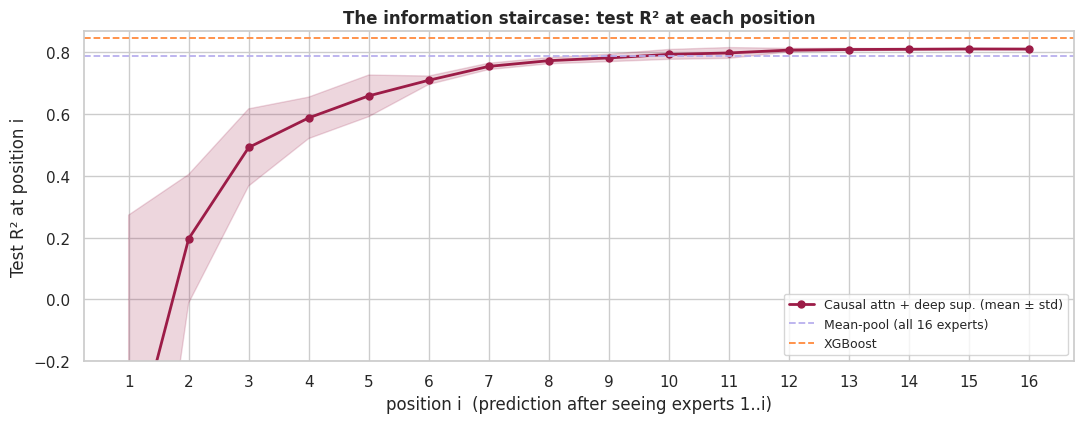

position,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
test R² (mean),-0.5471,0.1962,0.4915,0.5872,0.6583,0.7088,0.7537,0.7721,0.7811,0.7924,0.7971,0.8063,0.8082,0.8090,0.8099,0.8096
± std,0.8198,0.2079,0.1247,0.0670,0.0673,0.0137,0.0103,0.0101,0.0120,0.0160,0.0175,0.0057,0.0038,0.0028,0.0019,0.0022
gain over previous,NaN,0.7433,0.2954,0.0956,0.0711,0.0505,0.0448,0.0185,0.0089,0.0114,0.0047,0.0092,0.0019,0.0008,0.0009,-0.0003


In [13]:
curves = np.stack([by[("causal_ds", s)]["stage_r2"] for s in SEEDS])   # (seeds, K)
K = curves.shape[1]
pos = np.arange(1, K + 1)
mu, sd = curves.mean(0), curves.std(0)

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.fill_between(pos, mu - sd, mu + sd, color=COLOR["causal_ds"], alpha=.18)
ax.plot(pos, mu, "-o", color=COLOR["causal_ds"], lw=2, ms=5, label="Causal attn + deep sup. (mean ± std)")
ax.axhline(wide["meanpool"].mean(), color=COLOR["meanpool"], ls="--", lw=1.3, label="Mean-pool (all 16 experts)")
ax.axhline(XGB_TEST["r2"], color=COLOR["XGBoost"], ls="--", lw=1.3, label="XGBoost")
ax.set_xticks(pos); ax.set_xlabel("position i  (prediction after seeing experts 1..i)")
ax.set_ylabel("Test R² at position i")
ax.set_ylim(max(-0.2, (mu - sd).min() - 0.03), XGB_TEST["r2"] + 0.02)
ax.set_title("The information staircase: test R² at each position", fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

stair = pd.DataFrame({"position": pos, "test R² (mean)": mu, "± std": sd,
                      "gain over previous": np.r_[np.nan, np.diff(mu)]}).set_index("position")
display(stair.T.round(4))

## 10. Findings

*(Computed from the run above, so the text cannot drift from the numbers.)*

In [14]:
def fmt(name):
    r = decomp.loc[name]
    return (f"ΔR² = {r['mean ΔR²']:+.4f}  [95% CI {r['95% CI low']:+.4f} … {r['95% CI high']:+.4f}]"
            f"  wins {r['A wins']}  p={r['p (paired t)']:.3f}  -> {r['verdict']}")

M = {a: wide[a].mean() for a in wide.columns}
best_arm = max(ARMS, key=lambda a: M[a])
sep = "=" * 92
print(sep); print("FINDINGS — step 3: does attention earn its place?"); print(sep)

print("\nQ1. Is extra capacity alone worth anything?")
print("    " + fmt("Capacity"))

print("\nQ2. Does the proposed architecture beat a same-size plain alternative?   <- the key question")
print("    causal:        " + fmt("Causal attn vs same-size MLP"))
print("    bidirectional: " + fmt("Attention vs same-size MLP"))
print("    V2 recipe:     " + fmt("V2 recipe vs same-size MLP"))
v = decomp.loc["Causal attn vs same-size MLP", "verdict"]
if v == "REAL gain":
    print("    -> Attention is a better use of these parameters than a bigger MLP head.")
elif v == "REAL loss":
    print("    -> A plain wider head does BETTER than causal attention at the same size.")
else:
    print("    -> Causal attention is NOT distinguishable from simply spending the same parameters on a head.")

print("\nQ3. Does the causal ordering (the staircase) matter?")
print("    " + fmt("Causal ordering"))
v = decomp.loc["Causal ordering", "verdict"]
if v == "within noise":
    print("    -> No detectable difference between causal and bidirectional attention. On this dataset the")
    print("       ordering is not what drives performance; the GBDT-style 'staircase' is not doing measurable work.")
elif v == "REAL gain":
    print("    -> Causal beats bidirectional: the ordering itself carries value. This is the first direct")
    print("       evidence in the project that the staircase, not just attention, matters.")
else:
    print("    -> Bidirectional beats causal: restricting what experts can see costs accuracy here.")

print("\nQ4. Does deep supervision help?")
print("    " + fmt("Deep supervision"))

ent_m = ent.groupby("arm")[["block 1", "block 2"]].mean()
print("\nQ5. What did attention learn?")
for arm in ["causal", "bidirectional"]:
    e = ent_m.loc[LABEL[arm]]
    print(f"    {LABEL[arm]:20s} readout-row entropy  block1 {e['block 1']:.3f}  block2 {e['block 2']:.3f}"
          f"   (1.0 = uniform = mean-pooling)")
if ent_m.values.min() > 0.9:
    print("    -> The readout token spreads attention almost uniformly: attention is mostly AVERAGING the experts.")
    print("       Any gain it provides is more likely to come from its extra non-linear layers than from")
    print("       learning which experts to trust.")
else:
    print("    -> Attention is selective (well below uniform): it has learned to weight some experts more than others.")

print("\nQ6. The staircase curve (deep-supervision arm)")
mono = int((np.diff(mu) > 0).sum())
print(f"    position 1 R² = {mu[0]:.4f}  ->  position {K} R² = {mu[-1]:.4f}   "
      f"(rises at {mono}/{K-1} steps)")
half = int(np.argmax(mu >= mu[0] + 0.9 * (mu[-1] - mu[0]))) + 1
print(f"    90% of the total gain is reached by position {half} of {K}.")

print("\nQ7. Diversity")
dm = div.groupby("arm")["div"].mean()
print("    " + "   ".join(f"{LABEL[a]}: {dm[a]:.3f}" for a in ARMS))
print("    -> " + ("No arm collapses (all far below 1.0)." if dm.max() < 0.5 else
                  "At least one arm shows substantial convergence — investigate."))

print("\nQ8. Standing")
print(f"    best arm: {LABEL[best_arm]} at {M[best_arm]:.4f}   |   PlainMLP {M['PlainMLP']:.4f}   |   "
      f"XGBoost {XGB_TEST['r2']:.4f}")
print(f"    gap from best arm to XGBoost: {M[best_arm] - XGB_TEST['r2']:+.4f}")
print(f"    best arm vs PlainMLP: {M[best_arm] - M['PlainMLP']:+.4f}")
print("\n" + sep)

FINDINGS — step 3: does attention earn its place?

Q1. Is extra capacity alone worth anything?
    ΔR² = +0.0215  [95% CI +0.0121 … +0.0310]  wins 5/5  p=0.003  -> REAL gain

Q2. Does the proposed architecture beat a same-size plain alternative?   <- the key question
    causal:        ΔR² = -0.0031  [95% CI -0.0064 … +0.0003]  wins 1/5  p=0.066  -> within noise
    bidirectional: ΔR² = -0.0032  [95% CI -0.0103 … +0.0039]  wins 1/5  p=0.275  -> within noise
    V2 recipe:     ΔR² = -0.0008  [95% CI -0.0072 … +0.0056]  wins 3/5  p=0.748  -> within noise
    -> Causal attention is NOT distinguishable from simply spending the same parameters on a head.

Q3. Does the causal ordering (the staircase) matter?
    ΔR² = +0.0002  [95% CI -0.0073 … +0.0076]  wins 3/5  p=0.951  -> within noise
    -> No detectable difference between causal and bidirectional attention. On this dataset the
       ordering is not what drives performance; the GBDT-style 'staircase' is not doing measurable work.

Q4. 

## 11. What this means for the project

Read the findings above against the claims the interim presentation made:

| Presentation claim | What this notebook tests |
|---|---|
| "Causal masking intrinsically solves expert collapse" | Section 8 + step 1: diversity holds even with **no attention at all**, so the credit belongs to feature bagging |
| "Mimics the stage-wise residual learning of GBDTs" | Q3 (does ordering matter?) and Q6 (does R² climb position by position?) |
| "Significantly outperforms standard MLPs" | Q8: best arm vs PlainMLP under an identical protocol |
| "Bridges the gap to tree-based ensembles" | Q8: gap to tuned XGBoost |

**Natural next steps** depend on the verdicts:
- If **causal ≈ bidirectional**, the ordering isn't doing work yet. The most direct fix is to make the boosting
  explicit, so each stage fits the *residual* of the stages before it, rather than hoping attention discovers it.
- If **attention ≈ wide head**, the attention stage is an expensive MLP. Its value would have to come from
  interpretability (which experts matter) rather than accuracy.
- Either way, **one dataset is not enough**: the presentation promised a larger benchmark suite, and California
  Housing has only 8 features, which is little room for 16 experts to specialise.